In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/processed/clean_eda_data.csv")

df["Date"] = pd.to_datetime(df["Date"])

df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,Year,Month
0,2025-12-21,6,18,11,2484,14,2025,December
1,2025-12-18,11,50,6,2472,16,2025,December
2,2025-12-17,7,31,11,2481,10,2025,December
3,2025-12-16,8,54,15,2468,9,2025,December
4,2025-12-15,11,42,9,2470,7,2025,December


In [3]:
df["Year"] = df["Date"].dt.year

df["Quarter"] = df["Date"].dt.quarter

df["Month"] = df["Date"].dt.month

df["Week"] = df["Date"].dt.isocalendar().week.astype(int)

df["Day"] = df["Date"].dt.day

df["DayOfWeek"] = df["Date"].dt.dayofweek

df["DayName"] = df["Date"].dt.day_name()

df["MonthName"] = df["Date"].dt.month_name()

df["IsMonthStart"] = df["Date"].dt.is_month_start.astype(int)

df["IsMonthEnd"] = df["Date"].dt.is_month_end.astype(int)

## 📌 Observation

Calendar-based features were extracted from the Date column to capture temporal characteristics.

## 📊 Business Interpretation

Operational demand may vary across months, quarters, and days of the week due to administrative processes, migration patterns, or reporting cycles.

## 💡 Key Insight

Calendar features allow forecasting models to learn recurring temporal patterns without requiring manual intervention.

In [4]:
TARGET = "Children in HHS Care"

df["Lag_1"] = df[TARGET].shift(1)

df["Lag_7"] = df[TARGET].shift(7)

df["Lag_14"] = df[TARGET].shift(14)

df["Lag_30"] = df[TARGET].shift(30)

In [5]:
lag_columns = ["Lag_1", "Lag_7", "Lag_14", "Lag_30"]

df[lag_columns].head(15)

,Lag_1,Lag_7,Lag_14,Lag_30
0,NaN,NaN,NaN,NaN
1,2484.0,NaN,NaN,NaN
2,2472.0,NaN,NaN,NaN
3,2481.0,NaN,NaN,NaN
4,2468.0,NaN,NaN,NaN
5,2470.0,NaN,NaN,NaN
6,2462.0,NaN,NaN,NaN
7,2437.0,2484.0,NaN,NaN
8,2439.0,2472.0,NaN,NaN
9,2443.0,2481.0,NaN,NaN


## 📌 Observation

Lag features preserve historical values of HHS Care at different time intervals.

## 📊 Business Interpretation

Current occupancy is often influenced by recent historical occupancy rather than changing independently each day.

## 💡 Key Insight

Lag features enable the forecasting model to learn temporal dependencies and improve predictive accuracy.

In [6]:
df["RollingMean_7"] = df[TARGET].rolling(7).mean()

df["RollingMean_14"] = df[TARGET].rolling(14).mean()

df["RollingMean_30"] = df[TARGET].rolling(30).mean()

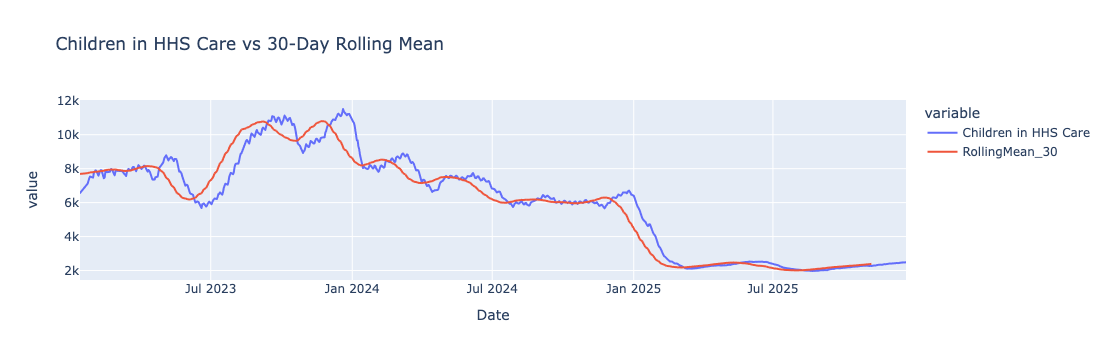

In [7]:
import plotly.express as px

fig = px.line(
    df,
    x="Date",
    y=["Children in HHS Care", "RollingMean_30"],
    title="Children in HHS Care vs 30-Day Rolling Mean"
)

fig.show()

## 📌 Observation

Rolling averages smooth short-term fluctuations and reveal the long-term movement of HHS Care occupancy.

## 📊 Business Interpretation

Decision-makers can use rolling averages to monitor sustained operational changes rather than reacting to daily variability.

## 💡 Key Insight

Rolling statistics improve model stability by capturing long-term trends.

In [8]:
df["RollingStd_7"] = df[TARGET].rolling(7).std()

df["RollingStd_30"] = df[TARGET].rolling(30).std()

## 📌 Observation

Rolling standard deviation quantifies the variability of HHS Care over time.

## 📊 Business Interpretation

Periods with higher variability may indicate operational uncertainty or sudden changes in system demand.

## 💡 Key Insight

Volatility features provide additional context beyond average occupancy levels.

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 25 columns):
 #   Column                                           Non-Null Count  Dtype         
---  ------                                           --------------  -----         
 0   Date                                             720 non-null    datetime64[us]
 1   Children apprehended and placed in CBP custody*  720 non-null    int64         
 2   Children in CBP custody                          720 non-null    int64         
 3   Children transferred out of CBP custody          720 non-null    int64         
 4   Children in HHS Care                             720 non-null    int64         
 5   Children discharged from HHS Care                720 non-null    int64         
 6   Year                                             720 non-null    int32         
 7   Month                                            720 non-null    int32         
 8   Quarter                                          72

In [10]:
df.head(10)

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,Year,Month,Quarter,Week,...,IsMonthEnd,Lag_1,Lag_7,Lag_14,Lag_30,RollingMean_7,RollingMean_14,RollingMean_30,RollingStd_7,RollingStd_30
0,2025-12-21,6,18,11,2484,14,2025,12,4,51,...,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-12-18,11,50,6,2472,16,2025,12,4,51,...,0,2484.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-12-17,7,31,11,2481,10,2025,12,4,51,...,0,2472.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-12-16,8,54,15,2468,9,2025,12,4,51,...,0,2481.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-12-15,11,42,9,2470,7,2025,12,4,51,...,0,2468.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,2025-12-14,8,35,4,2462,8,2025,12,4,50,...,0,2470.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,2025-12-11,7,47,9,2437,10,2025,12,4,50,...,0,2462.0,NaN,NaN,NaN,2467.714286,NaN,NaN,15.499616,NaN
7,2025-12-10,10,54,5,2439,9,2025,12,4,50,...,0,2437.0,2484.0,NaN,NaN,2461.285714,NaN,NaN,16.888993,NaN
8,2025-12-09,4,30,7,2443,8,2025,12,4,50,...,0,2439.0,2472.0,NaN,NaN,2457.142857,NaN,NaN,17.372666,NaN
9,2025-12-08,9,27,9,2440,4,2025,12,4,50,...,0,2443.0,2481.0,NaN,NaN,2451.285714,NaN,NaN,14.693698,NaN


In [11]:
TARGET = "Children in HHS Care"

df["RollingMin_7"] = df[TARGET].rolling(7).min()
df["RollingMax_7"] = df[TARGET].rolling(7).max()

df["RollingMin_30"] = df[TARGET].rolling(30).min()
df["RollingMax_30"] = df[TARGET].rolling(30).max()

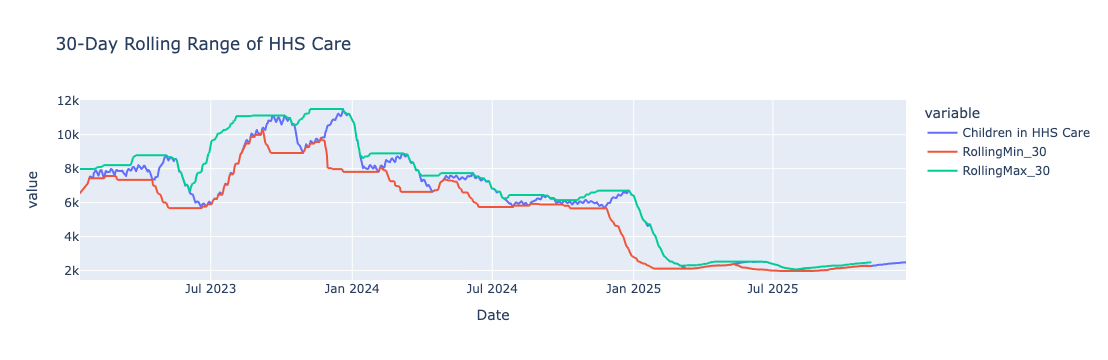

In [12]:
import plotly.express as px

fig = px.line(
    df,
    x="Date",
    y=["Children in HHS Care", "RollingMin_30", "RollingMax_30"],
    title="30-Day Rolling Range of HHS Care"
)

fig.show()

## 📌 Observation

The rolling minimum and maximum define the operating range of HHS Care over the previous 30 days.

## 📊 Business Interpretation

These features highlight periods where operational demand remains consistently high or low.

## 💡 Key Insight

Rolling ranges help identify shifts in capacity requirements and improve trend detection.

In [13]:
df["DailyChange"] = df[TARGET].diff()

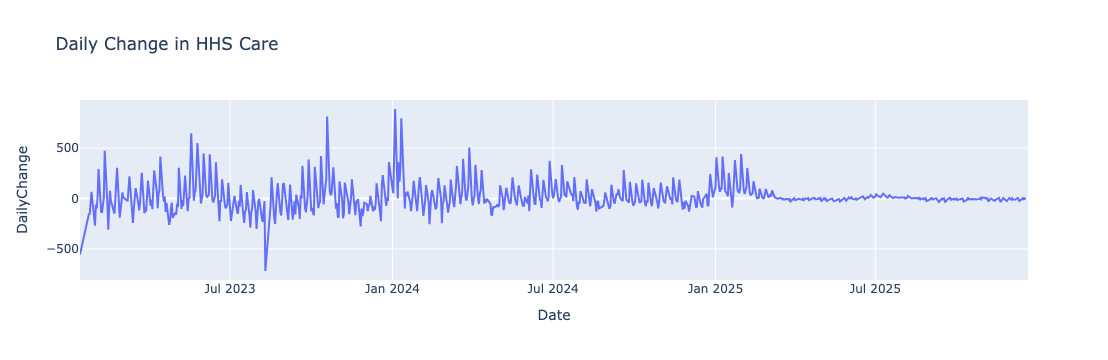

In [14]:
fig = px.line(
    df,
    x="Date",
    y="DailyChange",
    title="Daily Change in HHS Care"
)

fig.show()

## 📌 Observation

Daily changes fluctuate around zero with periods of larger increases and decreases.

## 📊 Business Interpretation

Large positive changes indicate rapid increases in occupancy, while negative values represent declining demand.

## 💡 Key Insight

Daily change provides a direct measure of operational momentum.

In [15]:
df["PctChange"] = df[TARGET].pct_change() * 100

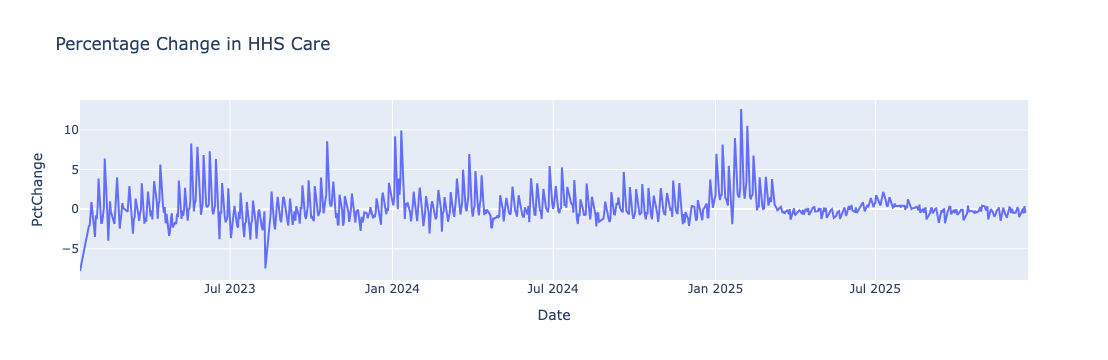

In [16]:
fig = px.line(
    df,
    x="Date",
    y="PctChange",
    title="Percentage Change in HHS Care"
)

fig.show()

## 📌 Observation

Percentage changes reveal relative fluctuations independent of absolute occupancy levels.

## 📊 Business Interpretation

This helps compare operational changes across periods with different population sizes.

## 💡 Key Insight

Relative change is often more informative than raw change during forecasting.

In [17]:
df["NetFlow"] = (
    df["Children transferred out of CBP custody"]
    - df["Children discharged from HHS Care"]
)

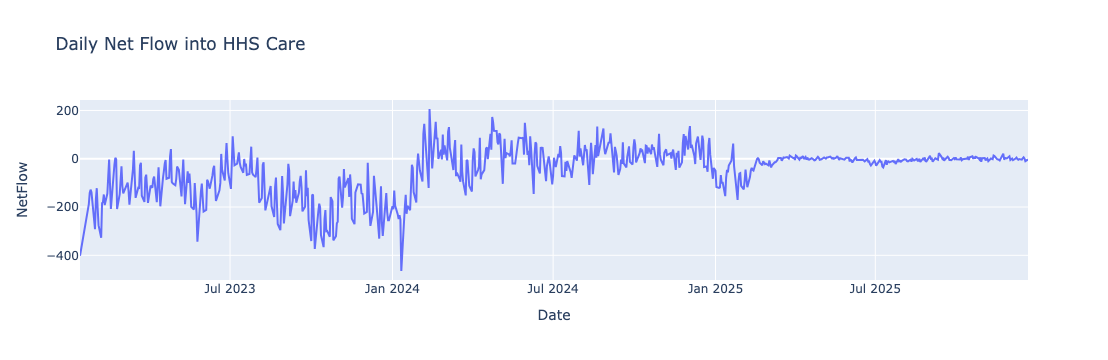

In [18]:
fig = px.line(
    df,
    x="Date",
    y="NetFlow",
    title="Daily Net Flow into HHS Care"
)

fig.show()

## 📌 Observation

Net flow measures the daily balance between admissions and discharges.

## 📊 Business Interpretation

Positive values indicate increasing pressure on HHS capacity, while negative values suggest declining occupancy.

## 💡 Key Insight

Net flow directly reflects operational pressure and is expected to be a strong forecasting feature.

In [19]:
df["TransferEfficiency"] = (
    df["Children transferred out of CBP custody"] /
    df["Children in CBP custody"]
)

In [20]:
df["TransferEfficiency"] = (
    df["TransferEfficiency"]
    .replace([np.inf, -np.inf], np.nan)
)

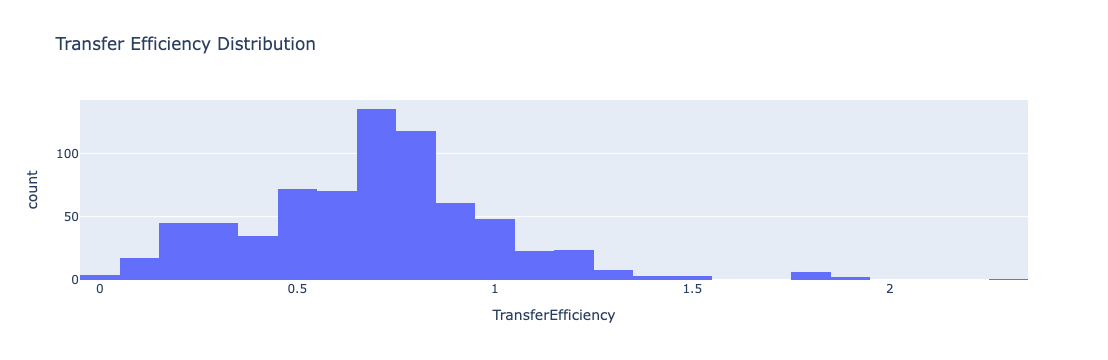

In [21]:
fig = px.histogram(
    df,
    x="TransferEfficiency",
    nbins=30,
    title="Transfer Efficiency Distribution"
)

fig.show()

## 📌 Observation

Transfer efficiency varies across the observation period.

## 📊 Business Interpretation

Higher efficiency indicates quicker movement from CBP custody to HHS care.

## 💡 Key Insight

Operational efficiency metrics provide additional predictive information beyond occupancy counts.

In [22]:
df["DischargeRatio"] = (
    df["Children discharged from HHS Care"] /
    df["Children in HHS Care"]
)

In [23]:
df["DischargeRatio"] = (
    df["DischargeRatio"]
    .replace([np.inf, -np.inf], np.nan)
)

## 📌 Observation

The discharge ratio measures the proportion of children leaving HHS Care each day.

## 📊 Business Interpretation

Higher discharge ratios reduce occupancy and relieve system pressure.

## 💡 Key Insight

This feature captures operational outflow efficiency and supports capacity forecasting.

In [24]:
df["OccupancyPressure"] = (
    df["Children in CBP custody"] +
    df["Children in HHS Care"]
)

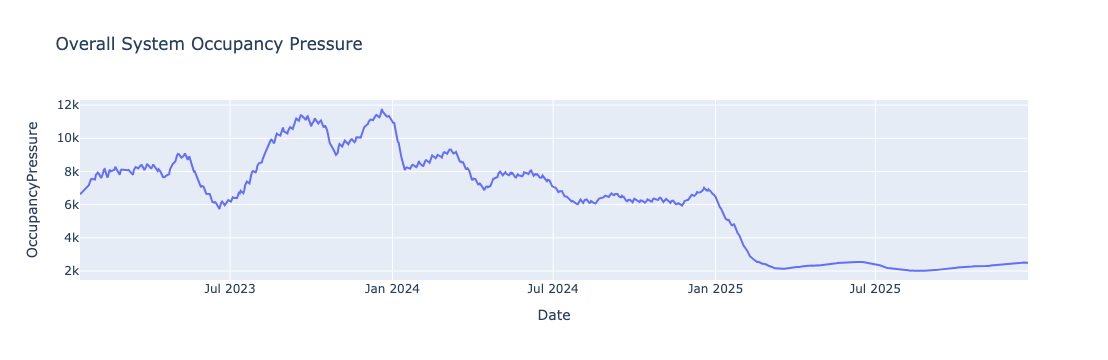

In [25]:
fig = px.line(
    df,
    x="Date",
    y="OccupancyPressure",
    title="Overall System Occupancy Pressure"
)

fig.show()

## 📌 Observation

The Occupancy Pressure Index combines the populations in CBP custody and HHS Care.

## 📊 Business Interpretation

This metric represents the total number of children being managed across both stages of the care system.

## 💡 Key Insight

The index provides a system-wide view of operational demand and can support strategic resource planning.

In [26]:
df["MonthSin"] = np.sin(2 * np.pi * df["Month"] / 12)
df["MonthCos"] = np.cos(2 * np.pi * df["Month"] / 12)

In [27]:
df["WeekdaySin"] = np.sin(2 * np.pi * df["DayOfWeek"] / 7)
df["WeekdayCos"] = np.cos(2 * np.pi * df["DayOfWeek"] / 7)

## 📌 Observation

Cyclical encoding preserves the natural repeating nature of months and weekdays.

## 📊 Business Interpretation

Seasonal patterns can now be learned without creating artificial discontinuities between the end and beginning of a cycle.

## 💡 Key Insight

Cyclical features improve the model's ability to learn recurring temporal behavior.

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 39 columns):
 #   Column                                           Non-Null Count  Dtype         
---  ------                                           --------------  -----         
 0   Date                                             720 non-null    datetime64[us]
 1   Children apprehended and placed in CBP custody*  720 non-null    int64         
 2   Children in CBP custody                          720 non-null    int64         
 3   Children transferred out of CBP custody          720 non-null    int64         
 4   Children in HHS Care                             720 non-null    int64         
 5   Children discharged from HHS Care                720 non-null    int64         
 6   Year                                             720 non-null    int32         
 7   Month                                            720 non-null    int32         
 8   Quarter                                          72

In [29]:
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,Year,Month,Quarter,Week,...,DailyChange,PctChange,NetFlow,TransferEfficiency,DischargeRatio,OccupancyPressure,MonthSin,MonthCos,WeekdaySin,WeekdayCos
0,2025-12-21,6,18,11,2484,14,2025,12,4,51,...,NaN,NaN,-3,0.611111,0.005636,2502,-2.449294e-16,1.0,-0.781831,0.623490
1,2025-12-18,11,50,6,2472,16,2025,12,4,51,...,-12.0,-0.483092,-10,0.120000,0.006472,2522,-2.449294e-16,1.0,0.433884,-0.900969
2,2025-12-17,7,31,11,2481,10,2025,12,4,51,...,9.0,0.364078,1,0.354839,0.004031,2512,-2.449294e-16,1.0,0.974928,-0.222521
3,2025-12-16,8,54,15,2468,9,2025,12,4,51,...,-13.0,-0.523982,6,0.277778,0.003647,2522,-2.449294e-16,1.0,0.781831,0.623490
4,2025-12-15,11,42,9,2470,7,2025,12,4,51,...,2.0,0.081037,2,0.214286,0.002834,2512,-2.449294e-16,1.0,0.000000,1.000000


In [30]:
df.tail()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,Year,Month,Quarter,Week,...,DailyChange,PctChange,NetFlow,TransferEfficiency,DischargeRatio,OccupancyPressure,MonthSin,MonthCos,WeekdaySin,WeekdayCos
715,2023-01-25,20,22,41,7538,180,2023,1,1,4,...,66.0,0.883298,-139,1.863636,0.023879,7560,0.5,0.866025,0.974928,-0.222521
716,2023-01-24,47,42,47,7433,175,2023,1,1,4,...,-105.0,-1.392942,-128,1.119048,0.023544,7475,0.5,0.866025,0.781831,0.623490
717,2023-01-23,32,50,39,7280,181,2023,1,1,4,...,-153.0,-2.058388,-142,0.780000,0.024863,7330,0.5,0.866025,0.000000,1.000000
718,2023-01-22,32,49,39,7122,227,2023,1,1,3,...,-158.0,-2.170330,-188,0.795918,0.031873,7171,0.5,0.866025,-0.781831,0.623490
719,2023-01-12,33,53,34,6566,436,2023,1,1,2,...,-556.0,-7.806796,-402,0.641509,0.066403,6619,0.5,0.866025,0.433884,-0.900969


In [31]:
df.isnull().sum()

Date                                                0
Children apprehended and placed in CBP custody*     0
Children in CBP custody                             0
Children transferred out of CBP custody             0
Children in HHS Care                                0
Children discharged from HHS Care                   0
Year                                                0
Month                                               0
Quarter                                             0
Week                                                0
Day                                                 0
DayOfWeek                                           0
DayName                                             0
MonthName                                           0
IsMonthStart                                        0
IsMonthEnd                                          0
Lag_1                                               1
Lag_7                                               7
Lag_14                      

In [33]:
print("Dataset Shape:", df.shape)

print("\nTotal Features:", len(df.columns))

print("\nFeature List:")
print(df.columns.tolist())

Dataset Shape: (720, 39)

Total Features: 39

Feature List:
['Date', 'Children apprehended and placed in CBP custody*', 'Children in CBP custody', 'Children transferred out of CBP custody', 'Children in HHS Care', 'Children discharged from HHS Care', 'Year', 'Month', 'Quarter', 'Week', 'Day', 'DayOfWeek', 'DayName', 'MonthName', 'IsMonthStart', 'IsMonthEnd', 'Lag_1', 'Lag_7', 'Lag_14', 'Lag_30', 'RollingMean_7', 'RollingMean_14', 'RollingMean_30', 'RollingStd_7', 'RollingStd_30', 'RollingMin_7', 'RollingMax_7', 'RollingMin_30', 'RollingMax_30', 'DailyChange', 'PctChange', 'NetFlow', 'TransferEfficiency', 'DischargeRatio', 'OccupancyPressure', 'MonthSin', 'MonthCos', 'WeekdaySin', 'WeekdayCos']


In [34]:
df.to_csv(
    "../data/feature_engineered/feature_engineered_data.csv",
    index=False
)

# Executive Summary – Feature Engineering

## Features Created

- Calendar Features
- Lag Features
- Rolling Statistics
- Growth Metrics
- Operational Ratios
- Net Flow
- Occupancy Pressure Index
- Cyclical Time Features

## Business Value

The engineered features capture historical trends, operational efficiency, temporal patterns, and system-wide capacity pressure. These features provide a richer representation of the care pipeline than the original dataset alone.

## Next Phase

The feature-engineered dataset is now ready for model development and forecasting.

# Feature Engineering Statistics

## Original Features
6

## Engineered Features
(Show the exact number)

## Total Features
(Show the total count)

## Target Variable
Children in HHS Care

## Missing Values Introduced

Lag Features:
Expected

Rolling Features:
Expected

These missing values will be removed before model training.

## Output File

feature_engineered_data.csv